In [ ]:
!git clone https://github.com/AbdelrahmanSaadIdress/HRN-Group-Activity-Recognition.git
%cd HRN-Group-Activity-Recognition

!pip install huggingface_hub wandb torch_geometric

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
GITHUB_TOKEN = user_secrets.get_secret("GITHUB_TOKEN")
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")
WANDB_API_KEY = user_secrets.get_secret("WANDB_API_KEY")

import os
os.environ["WANDB_API_KEY"] = WANDB_API_KEY
import huggingface_hub
huggingface_hub.login(token=HF_TOKEN)
import wandb
wandb.login(key=WANDB_API_KEY)

In [2]:
from huggingface_hub import HfApi, create_repo

MASTER_REPO = "AbdoSaad24/HRN-GAR-Best-Models"  # change if you want a different name
api = HfApi()
create_repo(MASTER_REPO, token=HF_TOKEN, exist_ok=True)
print(f"Master repo ready: https://huggingface.co/{MASTER_REPO}")

Master repo ready: https://huggingface.co/AbdoSaad24/HRN-GAR-Best-Models


In [ ]:
# from huggingface_hub import hf_hub_download, upload_file

# # model_name -> where its best.pt currently lives
# model_checkpoints = {
#     "B1-NoRelations":       {"repo_id": "AbdoSaad24/HRN_GAR",                    "filename": "best.pt"},
#     "RCRG-1R-1C":           {"repo_id": "AbdoSaad24/B2_stage2_tuned",            "filename": "best.pt"},
#     "RCRG-1R-1C-untuned":   {"repo_id": "AbdoSaad24/B3_stage2_untuned",          "filename": "best.pt"},
#     "RCRG-2R-11C":          {"repo_id": "AbdoSaad24/B4_stage2_RCRG_2R_11C",      "filename": "best.pt"},
#     "RCRG-2R-11C-conc":     {"repo_id": "AbdoSaad24/B4_stage2_RCRG_2R_11C_conc", "filename": "best.pt"},
#     "RCRG-2R-21C":          {"repo_id": "AbdoSaad24/RCRG_2R_21C",                "filename": "best.pt"},
#     "RCRG-2R-21C-conc":     {"repo_id": "AbdoSaad24/B4_stage2_RCRG_2R_21C_conc", "filename": "best.pt"},
#     "RCRG-3R-421C":         {"repo_id": "AbdoSaad24/B4_stage2_RCRG_3R_421C",     "filename": "best.pt"},
#     "RCRG-3R-421C-conc":    {"repo_id": "AbdoSaad24/B4_stage2_RCRG_3R_421C_conc","filename": "best.pt"},

#     "RCRG-2R-11C-conc-temporal":    {"repo_id": "AbdoSaad24/B4_stage2_Temporal_RCRG_2R_11C_conc_HGAR",      "filename": "best.pt"},
#     "RCRG-2R-21C-temporal":         {"repo_id": "AbdoSaad24/B4_stage2_Temporal_RCRG_2R_21C_HGAR",           "filename": "best.pt"},

#     "RCRG-2R-11C-conc-attention":    {"repo_id": "AbdoSaad24/B4_stage2_Attention_RCRG_2R_11C_conc_HGAR",   "filename": "best.pt"},
    
    
# }

# local_ckpt_paths = {}

# for model_name, info in model_checkpoints.items():
#     local_path = hf_hub_download(
#         repo_id=info["repo_id"],
#         filename=info["filename"],
#         token=HF_TOKEN,
#     )
#     upload_file(
#         path_or_fileobj=local_path,
#         path_in_repo=f"{model_name}/best.pt",
#         repo_id=MASTER_REPO,
#         token=HF_TOKEN,
#     )
#     local_ckpt_paths[model_name] = local_path
#     print(f"✅ {model_name} → {local_path} → uploaded to {MASTER_REPO}/{model_name}/best.pt")


from huggingface_hub import hf_hub_download, upload_file

# model_name -> where its best.pt currently lives
model_checkpoints = {
    "B1-NoRelations":       {"repo_id": "AbdoSaad24/HRN_GAR",                    "filename": "best.pt"},
    "RCRG-1R-1C":           {"repo_id": "AbdoSaad24/B2_stage2_tuned",            "filename": "best.pt"},
    "RCRG-1R-1C-untuned":   {"repo_id": "AbdoSaad24/B3_stage2_untuned",          "filename": "best.pt"},
    "RCRG-2R-11C":          {"repo_id": "AbdoSaad24/B4_stage2_RCRG_2R_11C",      "filename": "best.pt"},
    "RCRG-2R-11C-conc":     {"repo_id": "AbdoSaad24/B4_stage2_RCRG_2R_11C_conc", "filename": "best.pt"},
    "RCRG-2R-21C":          {"repo_id": "AbdoSaad24/RCRG_2R_21C",                "filename": "best.pt"},
    "RCRG-2R-21C-conc":     {"repo_id": "AbdoSaad24/B4_stage2_RCRG_2R_21C_conc", "filename": "best.pt"},
    "RCRG-3R-421C":         {"repo_id": "AbdoSaad24/B4_stage2_RCRG_3R_421C",     "filename": "best.pt"},
    "RCRG-3R-421C-conc":    {"repo_id": "AbdoSaad24/B4_stage2_RCRG_3R_421C_conc","filename": "best.pt"},

    "RCRG-2R-11C-conc-temporal":    {"repo_id": "AbdoSaad24/B4_stage2_Temporal_RCRG_2R_11C_conc_HGAR",      "filename": "best.pt"},
    "RCRG-2R-21C-temporal":         {"repo_id": "AbdoSaad24/B4_stage2_Temporal_RCRG_2R_21C_HGAR",           "filename": "best.pt"},

    "RCRG-2R-11C-conc-attention":    {"repo_id": "AbdoSaad24/B4_stage2_Attention_RCRG_2R_11C_conc_HGAR",   "filename": "best.pt"},
    
    
}

local_ckpt_paths = {}

for model_name, info in model_checkpoints.items():
    local_path = hf_hub_download(
        repo_id=info["repo_id"],
        filename=info["filename"],
        token=HF_TOKEN,
    )
    upload_file(
        path_or_fileobj=local_path,
        path_in_repo=f"{model_name}/best.pt",
        repo_id=MASTER_REPO,
        token=HF_TOKEN,
    )
    local_ckpt_paths[model_name] = local_path
    print(f"✅ {model_name} → {local_path} → uploaded to {MASTER_REPO}/{model_name}/best.pt")

In [4]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm.auto import tqdm

from DataSet.GetDataSet import get_dataloader
from DataSet.activities import group_activity_clases
from utils import load_config, load_checkpoint
from torch.utils.data import DataLoader


def evaluate_confusion_matrix(model_name, model, config, checkpoint_path):
    print(f"\n{'='*60}\nEvaluating: {model_name}\n{'='*60}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    load_checkpoint(
        config,
        model,
        checkpoint_path=checkpoint_path,
        test=True
    )

    model.to(device).eval()

    test_dataset, collate_fn = get_dataloader(config, "test")

    test_loader = DataLoader(
        test_dataset,
        batch_size=config["Modelling"]["batch_size"],
        shuffle=False,
        num_workers=config["Modelling"].get("num_workers", 4),
        collate_fn=collate_fn,
    )

    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, targets in tqdm(
            test_loader,
            desc=f"Evaluating {model_name}",
            unit="batch"
        ):
            inputs = inputs.to(device)

            outputs = model(inputs)

            preds = outputs.argmax(-1).cpu().numpy()

            y_true.extend(targets.numpy())
            y_pred.extend(preds)

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=group_activity_clases
    )

    fig, ax = plt.subplots(figsize=(8, 8))

    disp.plot(
        ax=ax,
        xticks_rotation=45,
        cmap="Blues"
    )

    ax.set_title(f"Confusion Matrix — {model_name}")

    plt.tight_layout()
    plt.show()

# Eval Of B1-NoReltions

In [8]:
%%writefile B1_NoRelations.yaml
About:
  name: "B1-NoRelations"
  level: "group"
  project_name: "HRN-GAR"
  repo_id: "AbdoSaad24/HRN-GAR-Best-Models"
  models_folder: "checkpoints/eval/B1-NoRelations"
  preload: "best"

Modelling:
  seed: 42
  num_classes: 8
  batch_size: 32
  num_workers: 4
  data_splits:
    train: [1, 3, 6, 7, 10, 13, 15, 16, 18, 22, 23, 31, 32, 36, 38, 39, 40, 41, 42, 48, 50, 52, 53, 54]
    val: [0, 2, 8, 12, 17, 19, 24, 26, 27, 28, 30, 33, 46, 49, 51]
    test: [4, 5, 9, 11, 14, 20, 21, 25, 29, 34, 35, 37, 43, 44, 45, 47]

Data:
  root: "/kaggle/working/Group-Activity-Recognition/src/Outputs/Part2"
  frames_annots_path: "/kaggle/input/datasets/ahmedmohamed365/volleyball/volleyball_/videos"
  annotations_path: "/kaggle/input/datasets/abdelrhmansaadidrees/annotations"
  weights_path: "/kaggle/working/dataset/weights"
  person_weights: "person_weights"
  group_weights: "group_weights"

Overwriting B1_NoRelations.yaml


  Config loaded: B1_NoRelations.yaml

Evaluating: B1-NoRelations
  [Checkpoint] Loading: /root/.cache/huggingface/hub/models--AbdoSaad24--HRN_GAR/snapshots/d9b7cfa866608b6c6a0967f6af17e3ab66674d25/best.pt
  [Checkpoint] Resumed from epoch 2  |  val_acc=86.5275%  |  global_step=304  |  wandb_run_id=u7muzi4d


Evaluating B1-NoRelations:   0%|          | 0/377 [00:00<?, ?batch/s]

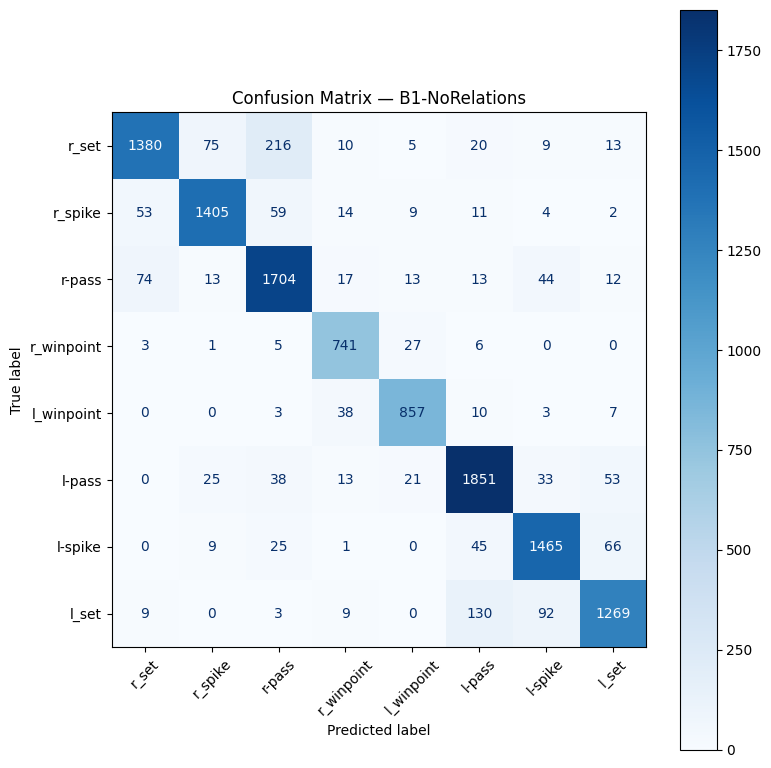

In [14]:
# ============================================================
# Model: B1-NoRelations
# ============================================================
from models.single_frame_models import b1_norelations_stage1, b1_norelations_stage2
from utils import load_config

config = load_config("B1_NoRelations.yaml")
stage1_shell = b1_norelations_stage1(num_classes=9)
model = b1_norelations_stage2(stage1_model=stage1_shell, num_classes=8)

evaluate_confusion_matrix(
    "B1-NoRelations", model, config,
    checkpoint_path=local_ckpt_paths["B1-NoRelations"],
)

# Eval Of Attention Model (The Best Model)

In [5]:
%%writefile RCRG_2R_11C_conc_attention.yaml
About:
  name: "RCRG-2R-11C-conc-attention"
  temporal: true
  attention: true
  level: "group"
  project_name: "HRN-GAR"
  repo_id: "AbdoSaad24/HRN-GAR-Best-Models"
  models_folder: "checkpoints/eval/RCRG-2R-11C-conc-attention"
  preload: "best"

Modelling:
  seed: 42
  num_classes: 8
  stage1_num_classes: 9
  in_channels: 1024
  hidden_channels: 512
  output_channels: [128, 256]
  batch_size: 4
  num_workers: 4
  data_splits:
    train: [1, 3, 6, 7, 10, 13, 15, 16, 18, 22, 23, 31, 32, 36, 38, 39, 40, 41, 42, 48, 50, 52, 53, 54]
    val: [0, 2, 8, 12, 17, 19, 24, 26, 27, 28, 30, 33, 46, 49, 51]
    test: [4, 5, 9, 11, 14, 20, 21, 25, 29, 34, 35, 37, 43, 44, 45, 47]

Data:
  root: "/kaggle/working/Group-Activity-Recognition/src/Outputs/Part2"
  frames_annots_path: "/kaggle/input/datasets/ahmedmohamed365/volleyball/volleyball_/videos"
  annotations_path: "/kaggle/input/datasets/abdelrhmansaadidrees/annotations"
  weights_path: "/kaggle/working/dataset/weights"
  person_weights: "person_weights"
  group_weights: "group_weights"

Writing RCRG_2R_11C_conc_attention.yaml


  Config loaded: RCRG_2R_11C_conc_attention.yaml
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]



Evaluating: RCRG-2R-11C-conc (Attention)
  [Checkpoint] Loading: /root/.cache/huggingface/hub/models--AbdoSaad24--B4_stage2_Attention_RCRG_2R_11C_conc_HGAR/snapshots/ab2f785215765e35ced22f8d0124606ab58c79cc/best.pt
  [Checkpoint] Resumed from epoch 32  |  val_acc=89.1872%  |  global_step=4320  |  wandb_run_id=uvblkns4


Evaluating RCRG-2R-11C-conc (Attention):   0%|          | 0/335 [00:00<?, ?batch/s]

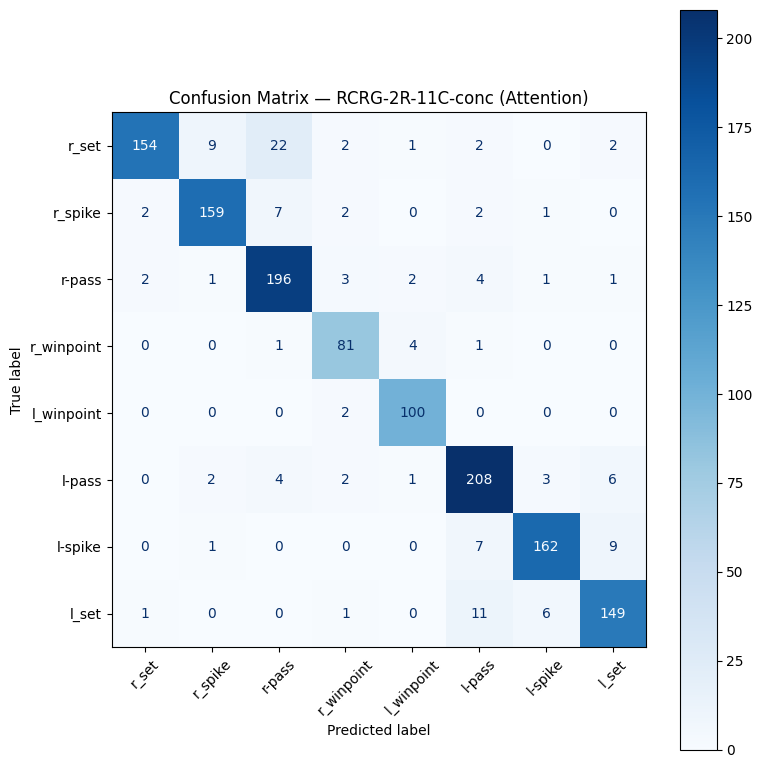

In [6]:
# ============================================================
# Model: RCRG-2R-11C-conc (Attention)
# ============================================================
from models.attention_models import RCRG_2R_11C_conc_stage2  
from models.single_frame_models import b1_norelations_stage1
from utils import load_config

config = load_config("RCRG_2R_11C_conc_attention.yaml")

stage1_shell = b1_norelations_stage1(num_classes=config["Modelling"]["stage1_num_classes"])

model = RCRG_2R_11C_conc_stage2(
    stage1_model=stage1_shell,
    in_channels=config["Modelling"]["in_channels"],       # 1024
    hidden_channels=config["Modelling"]["hidden_channels"],  # 512
    output_channels=config["Modelling"]["output_channels"],  # [128, 256]
    num_classes=config["Modelling"]["num_classes"],        # 8
)

evaluate_confusion_matrix(
    "RCRG-2R-11C-conc (Attention)", model, config,
    checkpoint_path=local_ckpt_paths["RCRG-2R-11C-conc-attention"],
)